In [1]:
import pandas as pd

df = pd.read_csv("dataset_07_student_placement_eligibility.csv")

df.head()

,cgpa,attendance_pct,coding_score,projects_completed,internship_months,backlogs,target
0,8.18,76.43,4,3,14,4,1
1,9.28,46.50,3,3,50,5,0
2,7.61,30.59,6,2,25,2,1
3,7.47,50.98,0,4,56,3,0
4,6.17,25.42,2,2,55,4,1


In [2]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

Dataset Shape: (1000, 7)

Column Names:
Index(['cgpa', 'attendance_pct', 'coding_score', 'projects_completed',
       'internship_months', 'backlogs', 'target'],
      dtype='object')

Missing Values:
cgpa                  0
attendance_pct        0
coding_score          0
projects_completed    0
internship_months     0
backlogs              0
target                0
dtype: int64

Duplicate Rows:
0

Target Distribution:
target
1    500
0    500
Name: count, dtype: int64


In [3]:
print(df.describe())

              cgpa  attendance_pct  coding_score  projects_completed  \
count  1000.000000     1000.000000   1000.000000         1000.000000   
mean      7.262610       50.859510      2.999000            2.976000   
std       1.255403       20.161735      1.711119            1.749424   
min       4.000000        0.000000      0.000000            0.000000   
25%       6.470000       37.447500      2.000000            2.000000   
50%       7.270000       50.595000      3.000000            3.000000   
75%       8.102500       64.027500      4.000000            4.000000   
max      10.000000      100.000000     10.000000            9.000000   

       internship_months     backlogs      target  
count        1000.000000  1000.000000  1000.00000  
mean           30.539000     2.988000     0.50000  
std            17.195935     1.722447     0.50025  
min             1.000000     0.000000     0.00000  
25%            16.000000     2.000000     0.00000  
50%            30.000000     3.000000  

In [4]:
print("CGPA range:", df["cgpa"].min(), "to", df["cgpa"].max())
print("Attendance range:", df["attendance_pct"].min(), "to", df["attendance_pct"].max())
print("Coding score range:", df["coding_score"].min(), "to", df["coding_score"].max())
print("Projects range:", df["projects_completed"].min(), "to", df["projects_completed"].max())
print("Internship months range:", df["internship_months"].min(), "to", df["internship_months"].max())
print("Backlogs range:", df["backlogs"].min(), "to", df["backlogs"].max())

CGPA range: 4.0 to 10.0
Attendance range: 0.0 to 100.0
Coding score range: 0 to 10
Projects range: 0 to 9
Internship months range: 1 to 60
Backlogs range: 0 to 9


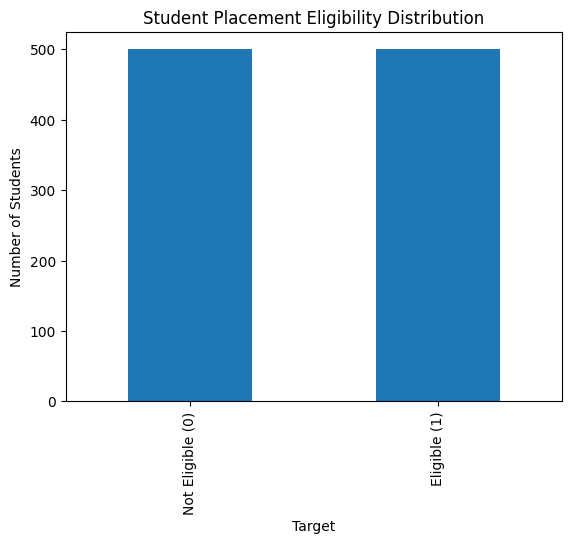

In [5]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")

plt.title("Student Placement Eligibility Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Students")
plt.xticks([0, 1], ["Not Eligible (0)", "Eligible (1)"])
plt.show()

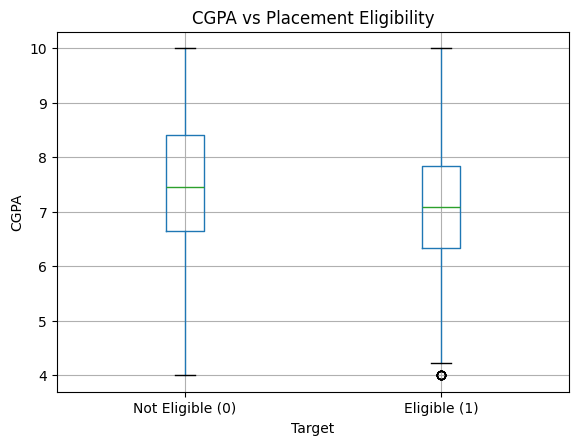

In [6]:
df.boxplot(column="cgpa", by="target")

plt.title("CGPA vs Placement Eligibility")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("CGPA")
plt.xticks([1, 2], ["Not Eligible (0)", "Eligible (1)"])
plt.show()

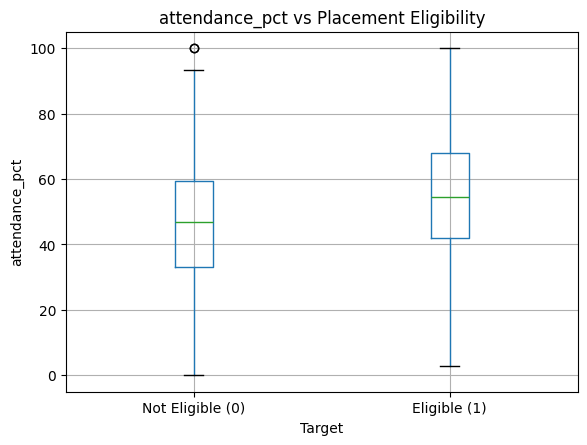

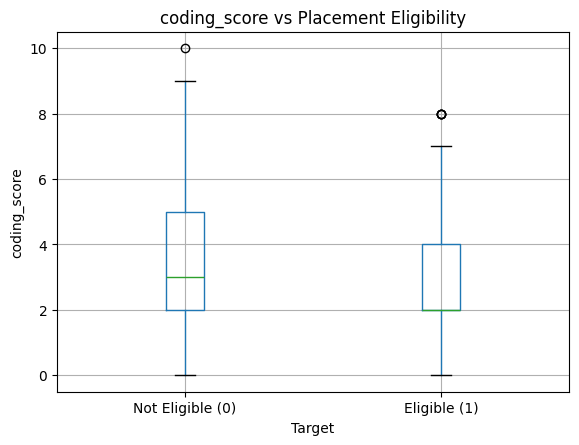

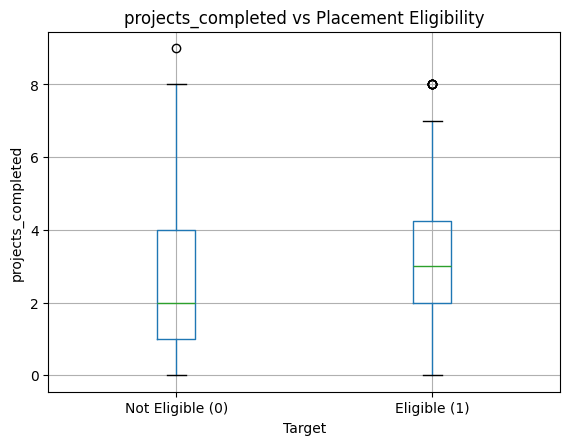

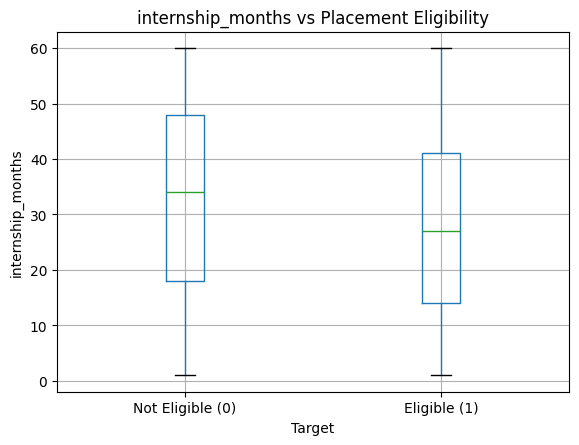

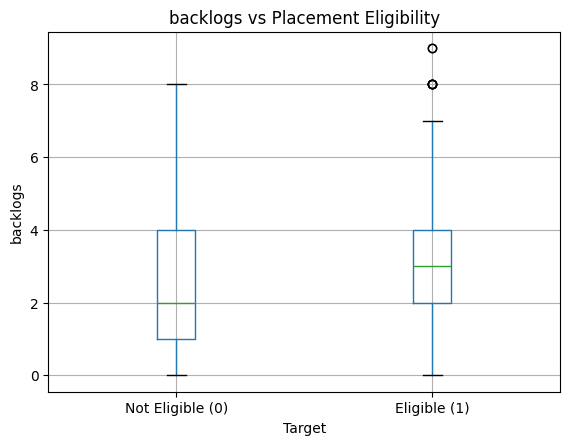

In [7]:
features = [
    "attendance_pct",
    "coding_score",
    "projects_completed",
    "internship_months",
    "backlogs"
]

for feature in features:
    df.boxplot(column=feature, by="target")
    plt.title(f"{feature} vs Placement Eligibility")
    plt.suptitle("")
    plt.xlabel("Target")
    plt.ylabel(feature)
    plt.xticks([1, 2], ["Not Eligible (0)", "Eligible (1)"])
    plt.show()

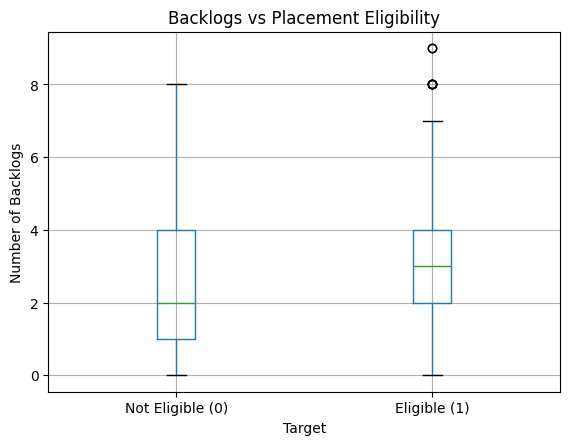

In [8]:
df.boxplot(column="backlogs", by="target")

plt.title("Backlogs vs Placement Eligibility")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Number of Backlogs")
plt.xticks([1, 2], ["Not Eligible (0)", "Eligible (1)"])
plt.show()

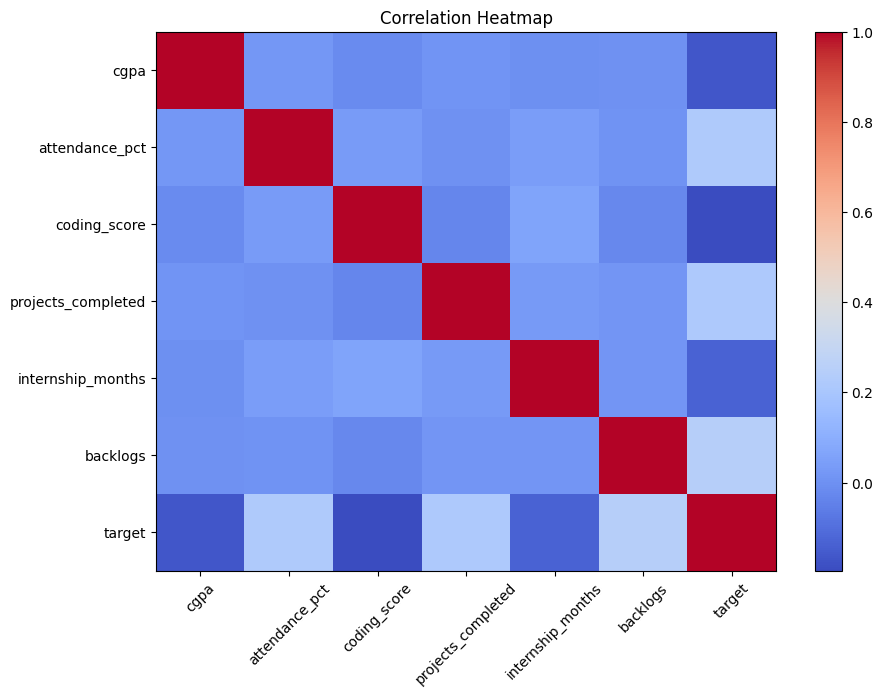

In [9]:
import matplotlib.pyplot as plt

correlation = df.corr()

plt.figure(figsize=(10, 7))
plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 6)
y shape: (1000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 6)
Testing data: (200, 6)


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 0
 1 0 1 1 1 0 0 0 1 1 0 1 0 0 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0
 1 1 0 1 1 0 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 0
 0 1 1 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 0 1 1 0 1 1 0 1 1
 1 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 1 1
 1 1 1 0 1 0 0 1 1 1 1 0 1 1 0]


In [14]:
y_probability = model.predict_proba(X_test)

print(y_probability[:10])

[[0.6433014  0.3566986 ]
 [0.82733113 0.17266887]
 [0.47797113 0.52202887]
 [0.75937535 0.24062465]
 [0.31810503 0.68189497]
 [0.67660961 0.32339039]
 [0.19489655 0.80510345]
 [0.38580667 0.61419333]
 [0.41095468 0.58904532]
 [0.78374404 0.21625596]]


In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.6886792452830188
Recall: 0.73
F1 Score: 0.7087378640776699


In [17]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7873


Confusion Matrix:
[[67 33]
 [27 73]]


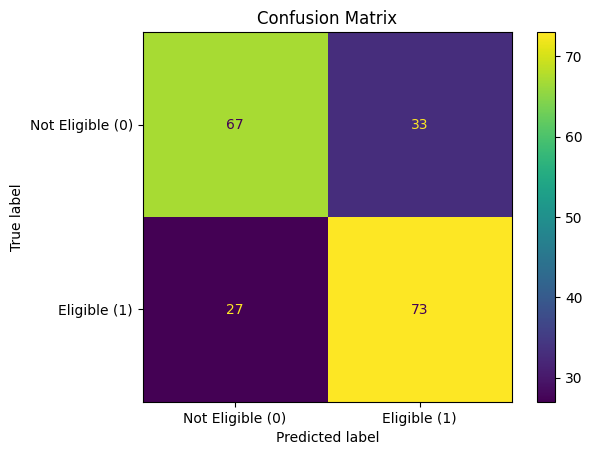

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Eligible (0)", "Eligible (1)"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [19]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

              Feature  Coefficient
5            backlogs     0.368014
3  projects_completed     0.318701
1      attendance_pct     0.028213
4   internship_months    -0.023373
2        coding_score    -0.303601
0                cgpa    -0.371978


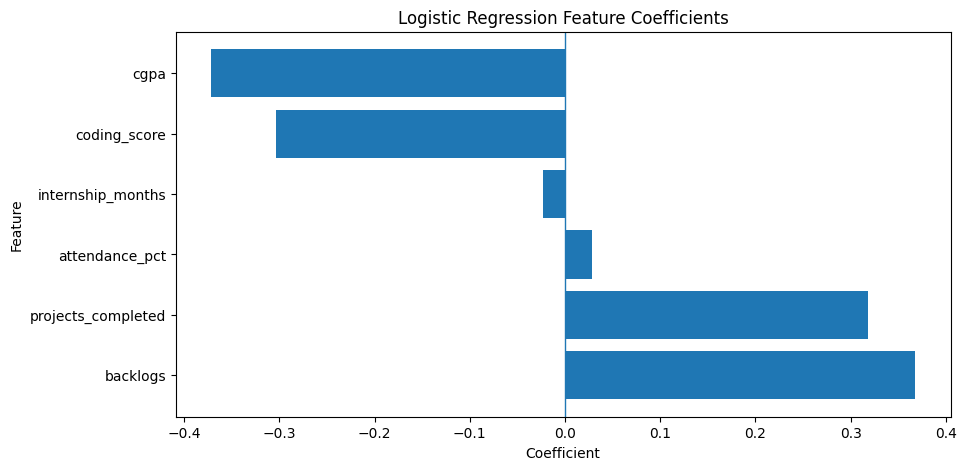

In [20]:
plt.figure(figsize=(10, 5))

plt.barh(coefficients["Feature"], coefficients["Coefficient"])

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")
plt.axvline(0, linewidth=1)

plt.show()